<a href="https://colab.research.google.com/github/Nikoldbautista/ANALISIS_EXPLORATORIO_DE_DATOS/blob/main/Taller_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
departamentos = ["santander", "atlantico", "norte de satander"]
capitales = ["Bucaramanga", "Barranquilla", "Cucuta"]

In [4]:
print(type(departamentos))

<class 'list'>


In [5]:
colombia = dict(zip(departamentos, capitales))#Funcion para crear diccionarios dict

In [6]:
colombia

{'santander': 'Bucaramanga',
 'atlantico': 'Barranquilla',
 'norte de satander': 'Cucuta'}

In [8]:
colombia["Valle del cauca"] = colombia

In [9]:
municipios = ["Floridablanca", "Giron", "Piedecuesta"]

In [11]:
entidades = {"Santander": municipios}

In [12]:
entidades

{'Santander': ['Floridablanca', 'Giron', 'Piedecuesta']}

In [24]:
entidades["Santander"][-1]

'Piedecuesta'

In [34]:
for dep,cap in colombia.items():
  print(dep,cap)

santander Bucaramanga
atlantico Barranquilla
norte de satander Cucuta
Valle del cauca {'santander': 'Bucaramanga', 'atlantico': 'Barranquilla', 'norte de satander': 'Cucuta', 'Valle del cauca': {...}}


In [27]:
holidays = pd.read_csv("https://raw.githubusercontent.com/Gustavo-Bruges/ciencia-de-datos-unab/refs/heads/datos/holidays.csv")

In [68]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16854 entries, 0 to 16853
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ISO3           16854 non-null  object  
 1   Year           16854 non-null  int64   
 2   Month          16854 non-null  category
 3   Total          9672 non-null   float64 
 4   Domestic       8132 non-null   float64 
 5   International  9151 non-null   float64 
 6   Total_OS       15151 non-null  float64 
 7   ADM_name       15060 non-null  object  
 8   Date           15060 non-null  object  
 9   Name           15060 non-null  object  
 10  Type           15060 non-null  category
dtypes: category(2), float64(4), int64(1), object(4)
memory usage: 1.2+ MB


In [98]:
holidays_pub_obs = holidays[holidays['Type'].isin(['Public holiday', 'Observance'])]

In [99]:
holidays_pub_obs.head()

,ISO3,Year,Month,Total,Domestic,International,Total_OS,ADM_name,Date,Name,Type
0,ALB,2010,1,NaN,NaN,NaN,117.350,Albania,2010-01-01,New Year's Day,Public holiday
1,ALB,2010,1,NaN,NaN,NaN,117.350,Albania,2010-01-02,New Year's Day (Day 2),Public holiday
2,ALB,2010,2,NaN,NaN,NaN,86.535,Albania,2010-02-14,Valentine's Day,Observance
3,ALB,2010,3,NaN,NaN,NaN,103.795,Albania,2010-03-08,Mothers' Day,Observance
4,ALB,2010,3,NaN,NaN,NaN,103.795,Albania,2010-03-14,Summer Day,Public holiday


##**EJERCICIO 1:** Elige por lo menos dos varibales y trnasformalo a categoria, justifique su eleccion
---



Elegí la columna Type porque es una variable que clasifica los datos en unos pocos grupos o categorías (como se ve en el dataset).

In [66]:
holidays["Type"] = holidays["Type"].astype("category")

In [67]:
holidays["Type"].nbytes

16910

Elegí la columna Month para convertirla a categoría porque, aunque son números, en realidad representan etiquetas fijas (del 1 al 12). No tiene sentido matemático sumarlos o sacarles el promedio (por ejemplo, el "promedio" de los meses no nos dice nada útil), así que tratarlos como categorías es más correcto para el análisis. Además, al ser solo 12 valores que se repiten en miles de filas, el programa ahorra memoria y corre más rápido.

In [60]:
holidays["Month"] = holidays["Month"].astype("category")


In [61]:
holidays["Month"].nbytes

16950

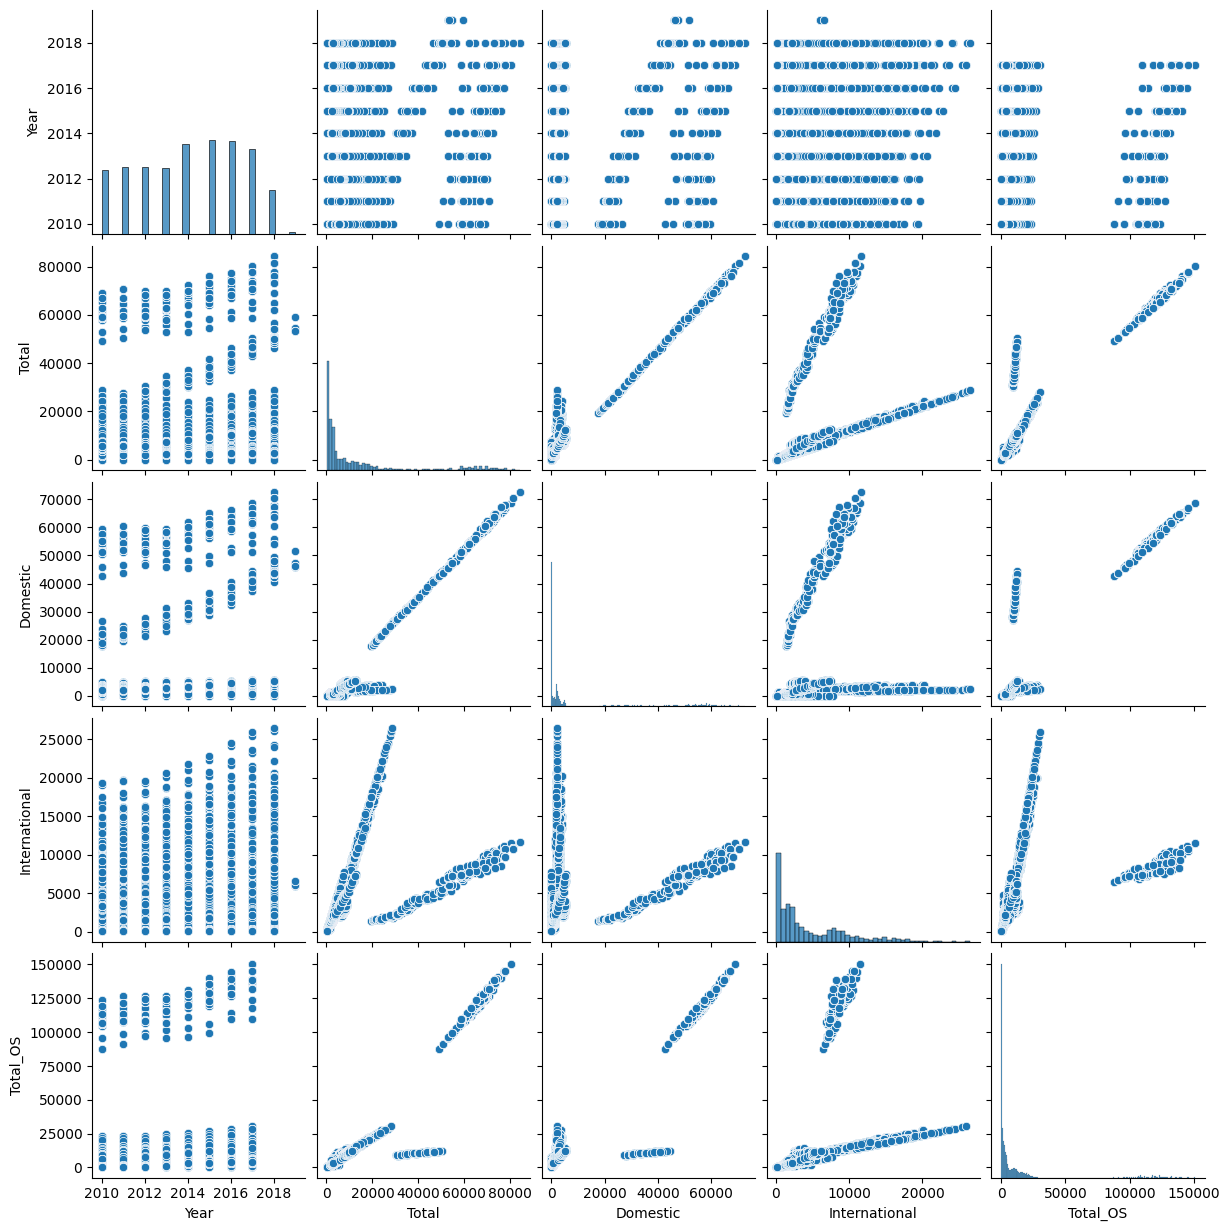

In [72]:
sns.pairplot(holidays)#Comparacion de todas las variables numericas
plt.show()

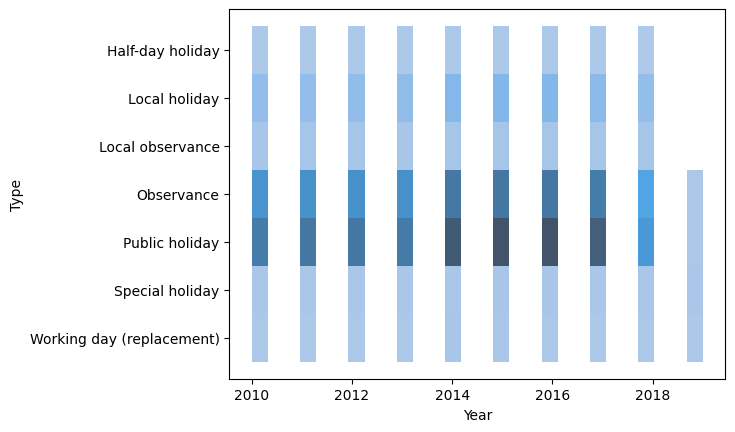

In [93]:
sns.set_palette("pastel")
sns.histplot(data=holidays, x="Year", y="Type", kde=True)
plt.show()

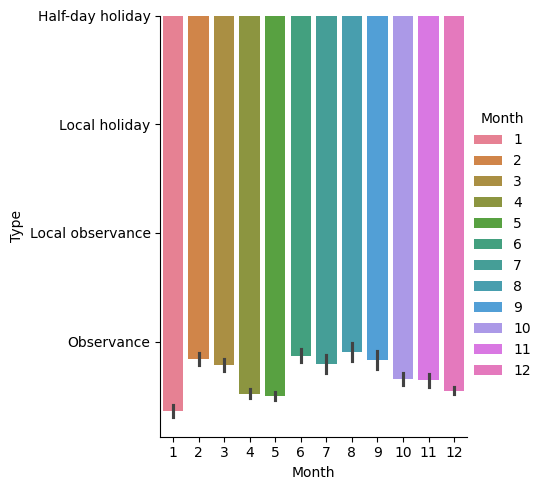

In [111]:
sns.catplot(data=holidays, x="Month", y="Type", kind="bar", hue="Month")